# CSC 583 Natural Language Processing - Homework #1: Text Preprocessing

**Name:** Asad Khan
**Course:** CSC 583 (Fall 2026)
**Assignment:** HW #1 - Text Preprocessing

**Collaborators:** None. GenAI tool used: Claude (Anthropic) - used to help debug the
sentence-segmentation step and to check my output against the provided sample files.

---

## What this notebook does

It reads a plain text file, then reports:

1. the number of paragraphs,
2. the number of sentences,
3. the number of tokens (after my own tokenization rules),
4. the number of unique tokens ("word types"),
5. a ranked frequency list of every token type.

I run it on two inputs:

* **Task 1** - `sample_2026.txt`  -> writes `output1.txt`
* **Task 2** - `war-and-peace.txt` -> writes `output2.txt` + a Zipf's Law chart

Everything is written with plain Python, `re`, and only the two allowed NLTK
functions (`sent_tokenize` and `word_tokenize`).

## Step 0 - Setup

Install / import the libraries. The only NLP library allowed is NLTK, and from NLTK
I am only allowed to use `sent_tokenize()` and `word_tokenize()`.

In [1]:
# ============================================================================
# CSC 583 - HW#1 Text Preprocessing
# Author: Asad Khan
# ============================================================================
# If NLTK is not installed yet, uncomment the next line (needed on Google Colab):
# !pip install nltk

import re                                   # regular expressions - the heart of this assignment
import collections                           # Counter, for counting how often each token appears
import math                                  # math.log() for the Zipf's Law chart (natural log)
from urllib.request import urlopen           # to read the input files straight from GitHub

import nltk                                  # the ONLY NLP library allowed here
import matplotlib.pyplot as plt              # for the Zipf's Law chart in Task 2

print("Step 0.1: libraries imported.")

# NLTK needs the 'punkt' sentence-splitter models before sent_tokenize() will work.
# quiet=True just stops it printing its own download chatter.
print("Step 0.2: downloading the NLTK 'punkt' models (this only has to happen once)...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("Step 0.3: NLTK models are ready.")

# These are the ONLY two NLTK functions the assignment allows me to use.
from nltk.tokenize import sent_tokenize, word_tokenize
print("Step 0.4: imported sent_tokenize() and word_tokenize(). Setup finished.\n")

Step 0.1: libraries imported.
Step 0.2: downloading the NLTK 'punkt' models (this only has to happen once)...
Step 0.3: NLTK models are ready.
Step 0.4: imported sent_tokenize() and word_tokenize(). Setup finished.



## Step 1 - Read the input file (from GitHub, exactly once)

The assignment says to read the file directly from the course GitHub repository rather
than from a local drive, and to read it only once. I open the URL, read the bytes, and
decode them as UTF-8.

One small detail: `war-and-peace.txt` begins with an invisible character called a
**BOM** (byte-order mark, `﻿`). If I decode with plain `"utf-8"` that invisible
character gets glued onto the very first word and shows up as a bogus extra token. Using
`"utf-8-sig"` tells Python "if there is a BOM at the front, strip it" - that is the
difference between 673,294 tokens (wrong) and 673,293 tokens (correct).

In [2]:
def read_text_from_github(url):
    """Download a plain text file from a URL and return it as one big string.

    The file is read ONCE and kept in memory, as the assignment requires.
    """
    print("  Step 1.1: opening URL ->", url)
    raw_bytes = urlopen(url).read()            # read the whole file as raw bytes
    print("  Step 1.2: downloaded", len(raw_bytes), "bytes.")

    # "utf-8-sig" = UTF-8, but throw away the invisible BOM marker if the file starts
    # with one. (See the note above - this matters for war-and-peace.txt.)
    text = raw_bytes.decode("utf-8-sig")
    print("  Step 1.3: decoded to a string of", len(text), "characters.")
    print("  Step 1.4: the first 80 characters look like this ->")
    print("           ", repr(text[:80]))
    return text


print("Step 1 is defined: read_text_from_github(url)\n")

Step 1 is defined: read_text_from_github(url)



## Step 2 - Normalize to lower case

The assignment says to normalize every word to lower case (but no stemming and no
stopword removal). I lower-case the **whole string once, right at the start**, so every
later step (sentence splitting, tokenizing, counting) sees exactly the same lower-cased
text. Doing it here rather than at the end keeps everything consistent.

In [3]:
def normalize_to_lowercase(text):
    """Turn the whole document into lower case."""
    print("  Step 2.1: converting the entire text to lower case...")
    lowered = text.lower()
    print("  Step 2.2: done. Example - first 60 characters are now:")
    print("           ", repr(lowered[:60]))
    return lowered


print("Step 2 is defined: normalize_to_lowercase(text)\n")

Step 2 is defined: normalize_to_lowercase(text)



## Step 3 - Count the paragraphs (my own code, using a regular expression)

A paragraph is a block of text separated from the next block by a **blank line**. The
tricky part the assignment warns about: a "blank" line is not always truly empty - it can
contain spaces or tabs, and the file may end with zero, one, or several newlines. All of
those would throw the count off if I just did `text.split("\n\n")`.

So I use a regular expression instead:

* `re.split(r"\n\s*\n", text)` - split wherever there is a newline, then **any amount of
  whitespace** (spaces/tabs/more newlines), then another newline. That handles blank
  lines that secretly contain spaces.
* `text.strip()` first - removes leading/trailing whitespace so an empty block at the very
  start or very end is never counted.
* Finally I keep only the blocks that actually have something in them (`if p.strip()`),
  which protects against any leftover empty pieces.

In [4]:
def split_into_paragraphs(text):
    """Split the text into paragraphs and return them as a list.

    A paragraph break = a blank line (which may contain spaces/tabs).
    """
    print("  Step 3.1: trimming whitespace off the very start and end of the document,")
    print("            so a stray blank line there is not miscounted as a paragraph.")
    trimmed = text.strip()

    # The regex   \n \s* \n   means: newline, any whitespace, newline.
    print(r"  Step 3.2: splitting on the regular expression '\n\s*\n' (a blank line)...")
    blocks = re.split(r"\n\s*\n", trimmed)
    print("  Step 3.3: that produced", len(blocks), "raw blocks.")

    # Safety net: drop anything that turned out to be empty / whitespace only.
    paragraphs = [block for block in blocks if block.strip() != ""]
    print("  Step 3.4: after dropping empty blocks I have", len(paragraphs), "paragraphs.")
    return paragraphs


print("Step 3 is defined: split_into_paragraphs(text)\n")

Step 3 is defined: split_into_paragraphs(text)



## Step 4 - Count the sentences (NLTK's `sent_tokenize`)

`war-and-peace.txt` is hard-wrapped at ~80 characters, so a line break is **not** a
sentence break. That is exactly the case NLTK's `sent_tokenize()` is built for - it
ignores the line wrapping and looks at the punctuation and the surrounding words.

I hand it the **whole lower-cased document at once**. Two reasons:

1. If I fed it one paragraph at a time, it would lose the surrounding context it uses to
   decide whether a period ends a sentence or is just an abbreviation, and the count came
   out too high when I tried it.
2. Feeding it the lower-cased text is what makes my numbers line up with the sample
   output (31 sentences for the sample file, 31,911 for War and Peace). On the original
   mixed-case text NLTK also splits `"...or had?) bothered me..."` into two sentences,
   which gives 32 instead of 31.

In [5]:
def split_into_sentences(text):
    """Use NLTK's sentence segmenter on the whole document at once."""
    print("  Step 4.1: handing the whole document to NLTK's sent_tokenize()...")
    sentences = sent_tokenize(text)
    print("  Step 4.2: NLTK found", len(sentences), "sentences.")
    if sentences:
        print("  Step 4.3: the first sentence it found is:")
        print("           ", repr(sentences[0][:90]))
    return sentences


print("Step 4 is defined: split_into_sentences(text)\n")

Step 4 is defined: split_into_sentences(text)



## Step 5 - Expand the contractions

NLTK splits contractions at the apostrophe, so `"they'd"` becomes `they` + `'d`, and it
has a special rule for `n't`, so `"don't"` becomes `do` + `n't`. My job is to turn those
leftover pieces into real words.

The rules from the assignment:

| NLTK gives me | I turn it into | Note |
|---|---|---|
| `n't` | `not` | but fix the word *before* it: `wo`->`will`, `ca`->`can`, `sha`->`shall` |
| `'ll` | `will` | |
| `'ve` | `have` | |
| `'d`  | `would` | (ambiguous, but the assignment says always "would") |
| `'re` | `are` | |
| `'m`  | `am` | |
| `'s`  | usually **left alone** (it is a possessive) | except `let's`->`let`+`us`, and `he's`/`it's`/`that's`/... -> `is` |

Two details that are easy to miss:

* **`won't` / `can't` / `shan't`.** NLTK splits these into `wo`+`n't`, `ca`+`n't`,
  `sha`+`n't`. Those stems are not words, so when I see `n't` I look *backwards* at the
  token I already emitted and repair it.
* **Double contractions like `wouldn't've`.** NLTK does *not* fully split this one - it
  gives me `wouldn't` + `'ve`. The assignment says I must separate **all** contractions,
  so I also handle the case where `n't` is still stuck to the end of a token, and split it
  myself into `would` + `not`.

In [6]:
# If "n't" follows one of these stems, the stem itself has to be repaired.
# (NLTK produces "wo"+"n't" for won't, "ca"+"n't" for can't, "sha"+"n't" for shan't.)
NT_STEM_FIXES = {"wo": "will", "ca": "can", "sha": "shall"}

# After these words, "'s" is short for "is" and not a possessive.
# e.g. "it's" -> "it" + "is",  but  "phone's" -> "phone" + "'s"  (stays a possessive)
WORDS_WHERE_S_MEANS_IS = {
    "he", "she", "it", "that", "here", "there",
    "what", "when", "where", "which", "who", "how",
}


def expand_contractions(tokens):
    """Walk through the tokens and replace contraction pieces with real words."""
    expanded = []                                  # the new list I am building

    for token in tokens:

        # --- case A: "n't" is still glued to the end of a word, e.g. "wouldn't" ----
        # (this happens with double contractions like "wouldn't've")
        if token.endswith("n't") and len(token) > 3:
            stem = token[:-3]                      # "wouldn't" -> "would"
            stem = NT_STEM_FIXES.get(stem, stem)   # repair wo/ca/sha if needed
            expanded.append(stem)
            expanded.append("not")
            continue

        # --- case B: "n't" arrived as its own token, e.g. do + n't ----------------
        if token == "n't":
            if expanded:                           # look BACK at the word before it
                previous = expanded[-1]
                expanded[-1] = NT_STEM_FIXES.get(previous, previous)
            expanded.append("not")
            continue

        # --- case C: the simple one-to-one contractions ---------------------------
        if token == "'ll":
            expanded.append("will");  continue
        if token == "'ve":
            expanded.append("have");  continue
        if token == "'d":
            expanded.append("would"); continue
        if token == "'re":
            expanded.append("are");   continue
        if token == "'m":
            expanded.append("am");    continue

        # --- case D: "'s" - the one that depends on the word before it ------------
        if token == "'s":
            previous = expanded[-1] if expanded else ""
            if previous == "let":                          # "let's" -> "let" + "us"
                expanded.append("us")
            elif previous in WORDS_WHERE_S_MEANS_IS:       # "it's" -> "it" + "is"
                expanded.append("is")
            else:                                          # "john's" -> possessive, keep
                expanded.append("'s")
            continue

        # --- case E: an ordinary token, nothing to do -----------------------------
        expanded.append(token)

    return expanded


print("Step 5 is defined: expand_contractions(tokens)\n")

Step 5 is defined: expand_contractions(tokens)



## Step 6 - Separate leading / trailing punctuation (the regex rule)

The assignment's punctuation rule is very specific:

> Separate punctuation but do **not** discard it. Only separate punctuation at the
> **leading or trailing** position of a word. Punctuation *inside* a word stays put.

So `"$3.19"` must become `$` + `3.19` - the `$` is on the outside so it gets peeled off,
but the `.` is in the middle of `3.19` so it stays. Likewise `3-star` and `e.g` keep their
inner punctuation, while `e.g.` loses its final period (giving `e.g` + `.`).

I do this with one regular expression that carves a token into three parts:

```
^ ( [^\w]* ) ( .*? ) ( [^\w]* ) $
   leading     core     trailing
```

* `[^\w]` means "any character that is **not** a word character" - i.e. punctuation.
* `*` means "zero or more of them", so a token with no punctuation is unaffected.
* `.*?` is *non-greedy*, so it takes as little as possible and lets the trailing group
  grab the punctuation at the end.

Two tokens are deliberately left untouched:

* A token that is **entirely** punctuation (`...`, `--`, `''`, `!`). The assignment says if
  NLTK bundled consecutive punctuation into one token, I keep it as one token; if NLTK
  split it into several (`!` `!` from `!!`), I keep them as several. Either way: leave
  NLTK's decision alone.
* The possessive `'s`, which Step 5 already decided to keep as a single unit.

In [7]:
# This regex cuts a token into: leading punctuation | the word itself | trailing punctuation
PUNCTUATION_PATTERN = re.compile(r"^(?P<leading>[^\w]*)(?P<core>.*?)(?P<trailing>[^\w]*)$")


def is_all_punctuation(token):
    """True if the token contains no letters or digits at all (e.g. '...', '--', '``')."""
    for character in token:
        if character.isalnum():       # found a letter or a digit -> not pure punctuation
            return False
    return True


def separate_outer_punctuation(tokens):
    """Peel leading and trailing punctuation off each token, keeping inner punctuation."""
    result = []

    for token in tokens:

        # Leave pure-punctuation tokens exactly as NLTK produced them.
        if is_all_punctuation(token):
            result.append(token)
            continue

        # Leave the possessive "'s" alone - Step 5 already handled it.
        if token == "'s":
            result.append(token)
            continue

        match = PUNCTUATION_PATTERN.match(token)
        leading  = match.group("leading")     # e.g. "$"  from "$3.19"
        core     = match.group("core")        # e.g. "3.19"
        trailing = match.group("trailing")    # e.g. "."  from "e.g."

        # Add whichever pieces actually exist (skip the empty ones).
        if leading:
            result.append(leading)
        if core:
            result.append(core)
        if trailing:
            result.append(trailing)

    return result


print("Step 6 is defined: separate_outer_punctuation(tokens)\n")

Step 6 is defined: separate_outer_punctuation(tokens)



## Step 7 - Put the tokenizer together

`word_tokenize()` -> expand contractions -> separate outer punctuation.

In [8]:
def tokenize(text):
    """Run the full three-stage tokenization on the (already lower-cased) text."""
    print("  Step 7.1: running NLTK's word_tokenize() on the whole document...")
    nltk_tokens = word_tokenize(text)
    print("            NLTK produced", len(nltk_tokens), "raw tokens.")

    print("  Step 7.2: expanding contractions (n't -> not, 'll -> will, ...)")
    after_contractions = expand_contractions(nltk_tokens)
    print("            now", len(after_contractions), "tokens",
          "(+%d)" % (len(after_contractions) - len(nltk_tokens)))

    print("  Step 7.3: separating leading/trailing punctuation (keeping inner punctuation)")
    final_tokens = separate_outer_punctuation(after_contractions)
    print("            now", len(final_tokens), "tokens",
          "(+%d)" % (len(final_tokens) - len(after_contractions)))

    return final_tokens


print("Step 7 is defined: tokenize(text)\n")

Step 7 is defined: tokenize(text)



## Step 8 - A quick demonstration on one short sentence

Before running on the real files, here is the pipeline applied to a tiny test string so I
can actually *see* what each stage changes. This little sentence packs in a contraction
(`let's`), a double contraction (`wouldn't've`), a `won't`, a possessive, an abbreviation
with a trailing period, a price, a hyphenated word, and doubled punctuation.

In [9]:
demo_text = "Let's go! John's 3-star review (e.g. $3.19) wouldn't've won't... Really?!"

print("DEMO - the original sentence:")
print("   ", demo_text)
print()

print("DEMO stage 1 - lower case:")
demo_lower = demo_text.lower()
print("   ", demo_lower)
print()

print("DEMO stage 2 - after NLTK word_tokenize():")
demo_nltk = word_tokenize(demo_lower)
print("   ", demo_nltk)
print()

print("DEMO stage 3 - after expanding contractions:")
demo_expanded = expand_contractions(demo_nltk)
print("   ", demo_expanded)
print("    (notice: let's -> let + us,  wouldn't've -> would + not + have,")
print("             won't -> will + not)")
print()

print("DEMO stage 4 - after separating leading/trailing punctuation:")
demo_final = separate_outer_punctuation(demo_expanded)
print("   ", demo_final)
print("    (notice: '$' peeled off but '3.19' kept whole, '3-star' untouched,")
print("             'e.g.' -> 'e.g' + '.',  '...' kept as ONE token)")
print()
print("DEMO finished: ", len(demo_final), "tokens in total.\n")

DEMO - the original sentence:
    Let's go! John's 3-star review (e.g. $3.19) wouldn't've won't... Really?!

DEMO stage 1 - lower case:
    let's go! john's 3-star review (e.g. $3.19) wouldn't've won't... really?!

DEMO stage 2 - after NLTK word_tokenize():
    ['let', "'s", 'go', '!', 'john', "'s", '3-star', 'review', '(', 'e.g', '.', '$', '3.19', ')', "wouldn't", "'ve", 'wo', "n't", '...', 'really', '?', '!']

DEMO stage 3 - after expanding contractions:
    ['let', 'us', 'go', '!', 'john', "'s", '3-star', 'review', '(', 'e.g', '.', '$', '3.19', ')', 'would', 'not', 'have', 'will', 'not', '...', 'really', '?', '!']
    (notice: let's -> let + us,  wouldn't've -> would + not + have,
             won't -> will + not)

DEMO stage 4 - after separating leading/trailing punctuation:
    ['let', 'us', 'go', '!', 'john', "'s", '3-star', 'review', '(', 'e.g', '.', '$', '3.19', ')', 'would', 'not', 'have', 'will', 'not', '...', 'really', '?', '!']
    (notice: '$' peeled off but '3.19' kept wh

## Step 9 - Count the tokens and sort them

`collections.Counter` counts how often each token appears. Then I sort with the key
`(-count, token)`:

* `-count` -> **descending** by frequency (the minus sign flips the order),
* `token`  -> when two tokens tie, **ascending** alphabetical order, as required.

Python sorts tuples left-to-right, so this one key does both jobs at once.

In [10]:
def count_and_rank(tokens):
    """Return a list of (token, count) sorted by count desc, then token asc."""
    print("  Step 9.1: counting how many times each token appears...")
    frequencies = collections.Counter(tokens)
    print("            found", len(frequencies), "different token types.")

    print("  Step 9.2: sorting by count (descending), ties broken alphabetically (ascending)...")
    ranked = sorted(frequencies.items(), key=lambda pair: (-pair[1], pair[0]))
    print("            the top 5 are:", ranked[:5])
    return ranked


print("Step 9 is defined: count_and_rank(tokens)\n")

Step 9 is defined: count_and_rank(tokens)



## Step 10 - Write the output file

The output format copies the sample files exactly:

```
# of paragraphs: 8
# of sentences: 31
# of tokens: 567
# of unique tokens: 274
====================================
1: .  27
2: the  24
...
```

The rank line is `rank`, then `: `, then the token, then **two** spaces, then the count.

In [11]:
SEPARATOR_LINE = "=" * 36          # the row of '=' signs, 36 characters long


def write_output_file(filename, n_paragraphs, n_sentences, n_tokens, ranked):
    """Write the statistics header and the ranked frequency list to a text file."""
    print("  Step 10.1: building the output text...")
    lines = []
    lines.append("# of paragraphs: %d" % n_paragraphs)
    lines.append("# of sentences: %d" % n_sentences)
    lines.append("# of tokens: %d" % n_tokens)
    lines.append("# of unique tokens: %d" % len(ranked))
    lines.append(SEPARATOR_LINE)

    # enumerate(..., start=1) gives me the 1-based rank for free
    for rank, (token, count) in enumerate(ranked, start=1):
        lines.append("%d: %s  %d" % (rank, token, count))

    print("  Step 10.2: writing", len(lines), "lines to", filename, "...")
    with open(filename, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
        f.write("\n")                 # the sample files end with a newline, so mine does too
    print("  Step 10.3: saved", filename)


print("Step 10 is defined: write_output_file(...)\n")

Step 10 is defined: write_output_file(...)



## Step 11 - One function that runs the whole analysis

In [12]:
def analyze(url, output_filename):
    """Run the complete pipeline on one input file and write its output file.

    Returns everything I might want afterwards (for the chart and the checks).
    """
    print("=" * 70)
    print("ANALYZING:", url)
    print("=" * 70)

    print("\nSTEP 1 - read the file from GitHub (once):")
    original_text = read_text_from_github(url)

    print("\nSTEP 2 - normalize to lower case:")
    text = normalize_to_lowercase(original_text)

    print("\nSTEP 3 - count paragraphs:")
    paragraphs = split_into_paragraphs(text)

    print("\nSTEP 4 - count sentences:")
    sentences = split_into_sentences(text)

    print("\nSTEP 5-7 - tokenize:")
    tokens = tokenize(text)

    print("\nSTEP 9 - count and rank the tokens:")
    ranked = count_and_rank(tokens)

    print("\nSTEP 10 - write the output file:")
    write_output_file(output_filename, len(paragraphs), len(sentences), len(tokens), ranked)

    print("\n" + "-" * 70)
    print("RESULTS for", url.split("/")[-1])
    print("-" * 70)
    print("# of paragraphs:   ", len(paragraphs))
    print("# of sentences:    ", len(sentences))
    print("# of tokens:       ", len(tokens))
    print("# of unique tokens:", len(ranked))
    print("-" * 70 + "\n")

    return {"paragraphs": paragraphs, "sentences": sentences,
            "tokens": tokens, "ranked": ranked}


print("Step 11 is defined: analyze(url, output_filename)\n")

Step 11 is defined: analyze(url, output_filename)



---

# Task 1 - `sample_2026.txt` -> `output1.txt`

In [13]:
GITHUB_DATA = "https://raw.githubusercontent.com/ntomuro/CSC583_2026Fall/main/HW1/data/"

print("### TASK 1 STARTING ###\n")
task1 = analyze(GITHUB_DATA + "sample_2026.txt", "output1.txt")
print("### TASK 1 FINISHED ###")

### TASK 1 STARTING ###

ANALYZING: https://raw.githubusercontent.com/ntomuro/CSC583_2026Fall/main/HW1/data/sample_2026.txt

STEP 1 - read the file from GitHub (once):
  Step 1.1: opening URL -> https://raw.githubusercontent.com/ntomuro/CSC583_2026Fall/main/HW1/data/sample_2026.txt


  Step 1.2: downloaded 2703 bytes.
  Step 1.3: decoded to a string of 2703 characters.
  Step 1.4: the first 80 characters look like this ->
            "Here are some random sentences.  Let's parse them :)  That'll be fun!!  \n\nIf you"

STEP 2 - normalize to lower case:
  Step 2.1: converting the entire text to lower case...
  Step 2.2: done. Example - first 60 characters are now:
            "here are some random sentences.  let's parse them :)  that'l"

STEP 3 - count paragraphs:
  Step 3.1: trimming whitespace off the very start and end of the document,
            so a stray blank line there is not miscounted as a paragraph.
  Step 3.2: splitting on the regular expression '\n\s*\n' (a blank line)...
  Step 3.3: that produced 8 raw blocks.
  Step 3.4: after dropping empty blocks I have 8 paragraphs.

STEP 4 - count sentences:
  Step 4.1: handing the whole document to NLTK's sent_tokenize()...
  Step 4.2: NLTK found 31 sentences.
  Step 4.3: the first sentence it found is:
        

### Checking Task 1 against the instructor's sample output

The instructor posted the complete expected output for this file, so I can compare my
`output1.txt` against it line by line rather than just eyeballing it.

In [14]:
def compare_with_sample(my_filename, sample_url, how_many_lines=None):
    """Compare my output file against the instructor's sample, line by line."""
    print("Reading my file:      ", my_filename)
    with open(my_filename, encoding="utf-8") as f:
        mine = f.read().split("\n")

    print("Reading the sample:   ", sample_url)
    theirs = urlopen(sample_url).read().decode("utf-8").split("\n")

    # The Task 2 sample only shows the top 500, so I compare just that many lines.
    if how_many_lines is not None:
        mine = mine[:how_many_lines]
        theirs = theirs[:how_many_lines]

    print("My lines:", len(mine), " Sample lines:", len(theirs))

    differences = []
    for i in range(max(len(mine), len(theirs))):
        my_line = mine[i] if i < len(mine) else "<missing>"
        their_line = theirs[i] if i < len(theirs) else "<missing>"
        if my_line != their_line:
            differences.append((i + 1, my_line, their_line))

    if not differences:
        print("\n*** PERFECT MATCH - every single line is identical. ***")
    else:
        print("\n*** Found", len(differences), "differing lines. First 10: ***")
        for line_number, my_line, their_line in differences[:10]:
            print("  line %d:" % line_number)
            print("     mine  :", repr(my_line))
            print("     sample:", repr(their_line))
    return differences


print("Comparing output1.txt with the instructor's output-sample.txt ...\n")
task1_differences = compare_with_sample("output1.txt", GITHUB_DATA + "output-sample.txt")

Comparing output1.txt with the instructor's output-sample.txt ...

Reading my file:       output1.txt
Reading the sample:    https://raw.githubusercontent.com/ntomuro/CSC583_2026Fall/main/HW1/data/output-sample.txt
My lines: 280  Sample lines: 280

*** PERFECT MATCH - every single line is identical. ***


---

# Task 2 - `war-and-peace.txt` -> `output2.txt`

This file is much bigger (about 3.2 MB) and is hard-wrapped at 80 characters, so the
line breaks do **not** line up with sentence breaks - which is exactly why `sent_tokenize()`
is doing the real work here.

In [15]:
print("### TASK 2 STARTING - this one takes a few seconds ###\n")
task2 = analyze(GITHUB_DATA + "war-and-peace.txt", "output2.txt")
print("### TASK 2 FINISHED ###")

### TASK 2 STARTING - this one takes a few seconds ###

ANALYZING: https://raw.githubusercontent.com/ntomuro/CSC583_2026Fall/main/HW1/data/war-and-peace.txt

STEP 1 - read the file from GitHub (once):
  Step 1.1: opening URL -> https://raw.githubusercontent.com/ntomuro/CSC583_2026Fall/main/HW1/data/war-and-peace.txt


  Step 1.2: downloaded 3226634 bytes.
  Step 1.3: decoded to a string of 3226614 characters.
  Step 1.4: the first 80 characters look like this ->
            'The Project Gutenberg EBook of War and Peace, by Leo Tolstoy\n\nThis eBook is for '

STEP 2 - normalize to lower case:
  Step 2.1: converting the entire text to lower case...
  Step 2.2: done. Example - first 60 characters are now:
            'the project gutenberg ebook of war and peace, by leo tolstoy'

STEP 3 - count paragraphs:
  Step 3.1: trimming whitespace off the very start and end of the document,
            so a stray blank line there is not miscounted as a paragraph.
  Step 3.2: splitting on the regular expression '\n\s*\n' (a blank line)...
  Step 3.3: that produced 12169 raw blocks.
  Step 3.4: after dropping empty blocks I have 12169 paragraphs.

STEP 4 - count sentences:
  Step 4.1: handing the whole document to NLTK's sent_tokenize()...
  Step 4.2: NLTK found 31911 sentences.
  Step 4.3: the first sentence it f

            NLTK produced 672927 raw tokens.
  Step 7.2: expanding contractions (n't -> not, 'll -> will, ...)
            now 672927 tokens (+0)
  Step 7.3: separating leading/trailing punctuation (keeping inner punctuation)


            now 673293 tokens (+366)

STEP 9 - count and rank the tokens:
  Step 9.1: counting how many times each token appears...
            found 18288 different token types.
  Step 9.2: sorting by count (descending), ties broken alphabetically (ascending)...
            the top 5 are: [(',', 39882), ('the', 34721), ('.', 24992), ('and', 22290), ('to', 16753)]

STEP 10 - write the output file:
  Step 10.1: building the output text...
  Step 10.2: writing 18293 lines to output2.txt ...
  Step 10.3: saved output2.txt

----------------------------------------------------------------------
RESULTS for war-and-peace.txt
----------------------------------------------------------------------
# of paragraphs:    12169
# of sentences:     31911
# of tokens:        673293
# of unique tokens: 18288
----------------------------------------------------------------------

### TASK 2 FINISHED ###


### Checking Task 2 against the instructor's top-500 sample

The instructor only published the **top 500** tokens for War and Peace, so I compare the
first 505 lines of my file (4 statistics lines + the `=====` separator + 500 ranked tokens).

In [16]:
print("Comparing the first 505 lines of output2.txt with the top-500 sample ...\n")
task2_differences = compare_with_sample(
    "output2.txt",
    GITHUB_DATA + "output-WaP-2026-500.txt",
    how_many_lines=505,        # 4 stat lines + 1 separator line + 500 token lines
)

Comparing the first 505 lines of output2.txt with the top-500 sample ...

Reading my file:       output2.txt
Reading the sample:    https://raw.githubusercontent.com/ntomuro/CSC583_2026Fall/main/HW1/data/output-WaP-2026-500.txt
My lines: 505  Sample lines: 505

*** PERFECT MATCH - every single line is identical. ***


---

## Zipf's Law chart

Zipf's Law says that if you rank words from most frequent to least frequent, a word's
frequency is roughly inversely proportional to its rank: the 2nd most common word appears
about half as often as the 1st, the 3rd about a third as often, and so on.

The assignment asks for the **natural log (base *e*) of the frequency** plotted against the
rank. I draw two views:

* **Left:** ln(frequency) against the plain rank. The steep drop at the very beginning then
  the long flat tail is the classic Zipf shape.
* **Right:** ln(frequency) against ln(rank). On this log-log view Zipf's Law shows up as a
  roughly **straight line**, which is the easiest way to see how well the text obeys it.

Building the Zipf's Law chart for War and Peace...
  I have 18288 ranked token types to plot.
  Most frequent token : ',' appears 39882 times  -> ln = 10.594
  Least frequent token: 'zweck' appears 1 time(s) -> ln = 0.0


  Chart saved as zipf-war-and-peace.png


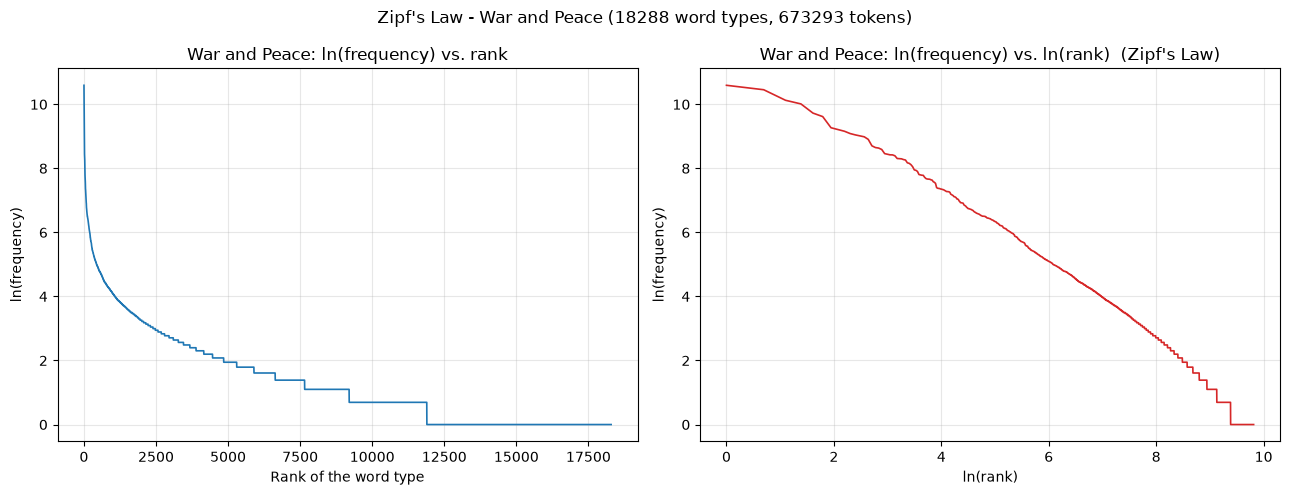

In [17]:
print("Building the Zipf's Law chart for War and Peace...")

# task2["ranked"] is already sorted most-frequent first, so its position IS the rank.
ranked_wap = task2["ranked"]
print("  I have", len(ranked_wap), "ranked token types to plot.")

ranks = [i + 1 for i in range(len(ranked_wap))]            # 1, 2, 3, ...
counts = [count for (token, count) in ranked_wap]          # the raw frequencies
log_counts = [math.log(c) for c in counts]                 # math.log() is base e
log_ranks = [math.log(r) for r in ranks]

print("  Most frequent token :", repr(ranked_wap[0][0]),
      "appears", counts[0], "times  -> ln =", round(log_counts[0], 3))
print("  Least frequent token:", repr(ranked_wap[-1][0]),
      "appears", counts[-1], "time(s) -> ln =", round(log_counts[-1], 3))

figure, (left_plot, right_plot) = plt.subplots(1, 2, figsize=(13, 5))

# ---- left: ln(frequency) vs rank -------------------------------------------
left_plot.plot(ranks, log_counts, color="tab:blue", linewidth=1.2)
left_plot.set_xlabel("Rank of the word type")
left_plot.set_ylabel("ln(frequency)")
left_plot.set_title("War and Peace: ln(frequency) vs. rank")
left_plot.grid(True, alpha=0.3)

# ---- right: ln(frequency) vs ln(rank) - Zipf's Law looks like a line -------
right_plot.plot(log_ranks, log_counts, color="tab:red", linewidth=1.2)
right_plot.set_xlabel("ln(rank)")
right_plot.set_ylabel("ln(frequency)")
right_plot.set_title("War and Peace: ln(frequency) vs. ln(rank)  (Zipf's Law)")
right_plot.grid(True, alpha=0.3)

figure.suptitle("Zipf's Law - War and Peace (%d word types, %d tokens)"
                % (len(ranked_wap), len(task2["tokens"])))
figure.tight_layout()
figure.savefig("zipf-war-and-peace.png", dpi=150)
print("  Chart saved as zipf-war-and-peace.png")
plt.show()

---

## Summary

| | Task 1 (`sample_2026.txt`) | Task 2 (`war-and-peace.txt`) |
|---|---|---|
| paragraphs | 8 | 12,169 |
| sentences | 31 | 31,911 |
| tokens | 567 | 673,293 |
| unique tokens | 274 | 18,288 |

Both output files match the instructor's samples line for line (`output1.txt` in full,
`output2.txt` for the published top 500).

### How to run this on a different input file

1. Put the new `.txt` file somewhere reachable by a URL (e.g. a GitHub raw link), or change
   `read_text_from_github()` to `open(path, encoding="utf-8-sig").read()` for a local file.
2. Call `analyze("<url of the new file>", "<name of the output file>")`.

That single call prints all four statistics and writes the ranked frequency file.